# 06 - Monitoring and Learning Agent

This notebook combines demand, pricing, utilization, waiting proxy, customer response, and revenue metrics into an executive monitoring layer.

Mentor requirements covered here:

- KPI Monitoring
- Revenue Monitoring
- Utilization Monitoring
- Demand Monitoring
- Waiting Time Monitoring
- Customer Response Monitoring
- Agent Feedback Loop
- Final executive dashboard output


## Assumptions

- Monitoring uses generated report files from notebooks 04 and 05.
- Waiting time is represented with a utilization pressure proxy.
- Customer response is estimated through the documented elasticity assumption.


In [59]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("../outputs/figures")
REPORT_DIR = Path("../outputs/reports")
FIG_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


## KPI Monitoring


In [60]:
demand_kpis = pd.read_csv(REPORT_DIR / "demand_agent_kpis.csv")
pricing_kpis = pd.read_csv(REPORT_DIR / "tariff_pricing_kpis.csv")
model_comparison = pd.read_csv(REPORT_DIR / "demand_model_comparison.csv")

def get_kpi(frame, name):
    return float(frame.loc[frame["KPI"] == name, "Value"].iloc[0])


final_kpis = pd.DataFrame(
    [
        {"KPI": "Revenue Gain %", "Value": get_kpi(pricing_kpis, "Revenue Gain %"), "Source": "ACN"},
        {"KPI": "Off-Peak Uplift %", "Value": get_kpi(demand_kpis, "Off-Peak Uplift %"), "Source": "UrbanEV"},
        {"KPI": "Utilization Improvement %", "Value": get_kpi(demand_kpis, "Utilization Improvement %"), "Source": "UrbanEV"},
        {"KPI": "Waiting Time Reduction %", "Value": get_kpi(demand_kpis, "Waiting Time Reduction %"), "Source": "UrbanEV proxy"},
        {"KPI": "Customer Response Rate %", "Value": get_kpi(pricing_kpis, "Customer Response Rate %"), "Source": "ACN + elasticity"},
        {"KPI": "Pricing Efficiency Score", "Value": get_kpi(pricing_kpis, "Pricing Efficiency Score"), "Source": "ACN"},
        {"KPI": "Demand Forecast Accuracy R2", "Value": get_kpi(demand_kpis, "Demand Forecast Accuracy R2"), "Source": "UrbanEV"},
        {"KPI": "Demand Forecast RMSE", "Value": get_kpi(demand_kpis, "Demand Forecast RMSE"), "Source": "UrbanEV"},
    ]
)

final_kpis.to_csv(REPORT_DIR / "final_kpis.csv", index=False)
final_kpis.to_csv(Path("../outputs/final_kpis.csv"), index=False)
final_kpis


,KPI,Value,Source
0,Revenue Gain %,0.978036,ACN
1,Off-Peak Uplift %,-1.841452,UrbanEV
2,Utilization Improvement %,-1.410991,UrbanEV
3,Waiting Time Reduction %,1.410991,UrbanEV proxy
4,Customer Response Rate %,-0.998470,ACN + elasticity
5,Pricing Efficiency Score,0.488466,ACN
6,Demand Forecast Accuracy R2,0.980850,UrbanEV
7,Demand Forecast RMSE,3.465161,UrbanEV


### Business Interpretation

This table is the executive view of the full agentic system. Every KPI maps directly to a mentor deliverable and identifies the dataset used.


## Revenue Monitoring


,KPI,Value
0,Baseline Revenue INR,2.025420e+06
1,Dynamic Pricing Revenue INR,2.045229e+06


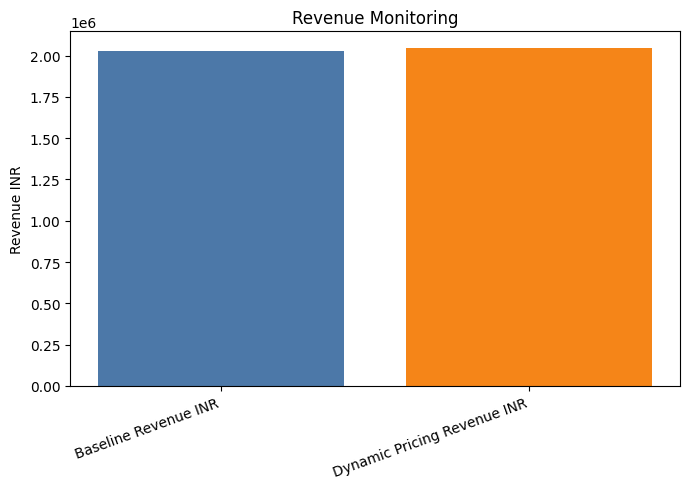

In [61]:
revenue_rows = pricing_kpis[pricing_kpis["KPI"].isin(["Baseline Revenue INR", "Dynamic Pricing Revenue INR"])]

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(revenue_rows["KPI"], revenue_rows["Value"], color=["#4c78a8", "#f58518"])
ax.set_title("Revenue Monitoring")
ax.set_ylabel("Revenue INR")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "monitoring_revenue.png", dpi=160)
revenue_rows


## Utilization Monitoring


,grid,avg_utilization_before,avg_utilization_after,charger_count
0,1029,0.752757,0.733366,36.0
1,715,0.717630,0.694378,13.0
2,570,0.623573,0.602685,21.0
3,991,0.612553,0.597867,23.0
4,732,0.599806,0.585411,43.0
5,1131,0.584118,0.569844,92.0
6,712,0.576817,0.562973,90.0
7,102,0.559380,0.545954,30.0
8,835,0.559257,0.545827,12.0
9,522,0.548658,0.535608,110.0


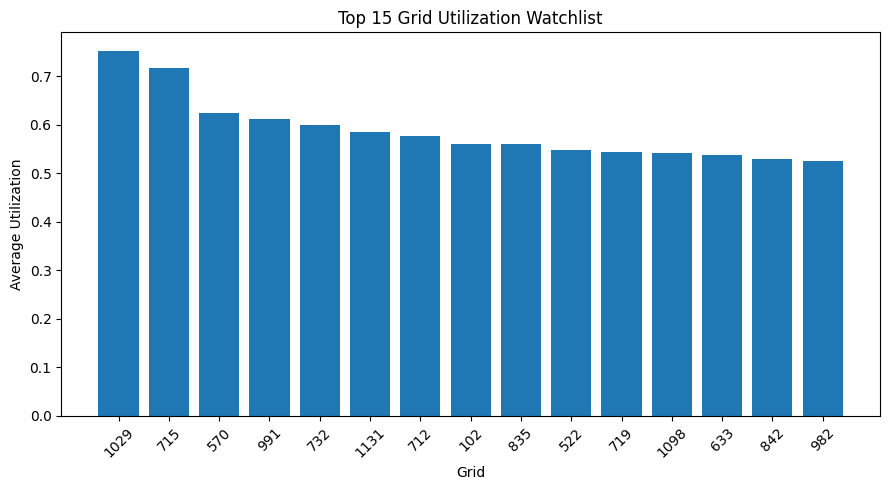

In [62]:
grid_utilization = pd.read_csv(REPORT_DIR / "grid_utilization_summary.csv")
utilization_watchlist = grid_utilization.head(15).copy()

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(utilization_watchlist["grid"].astype(str), utilization_watchlist["avg_utilization_before"])
ax.set_title("Top 15 Grid Utilization Watchlist")
ax.set_xlabel("Grid")
ax.set_ylabel("Average Utilization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "monitoring_utilization_watchlist.png", dpi=160)
utilization_watchlist


## Demand Monitoring


,model,MAE,RMSE,R2,MAPE_percent
0,XGBRegressor,1.928933,3.465161,0.980850,15.390332
1,Ridge_Regression,2.369891,4.450786,0.968407,18.999777
2,Baseline_lag_12,3.442599,7.032456,0.921125,22.403639


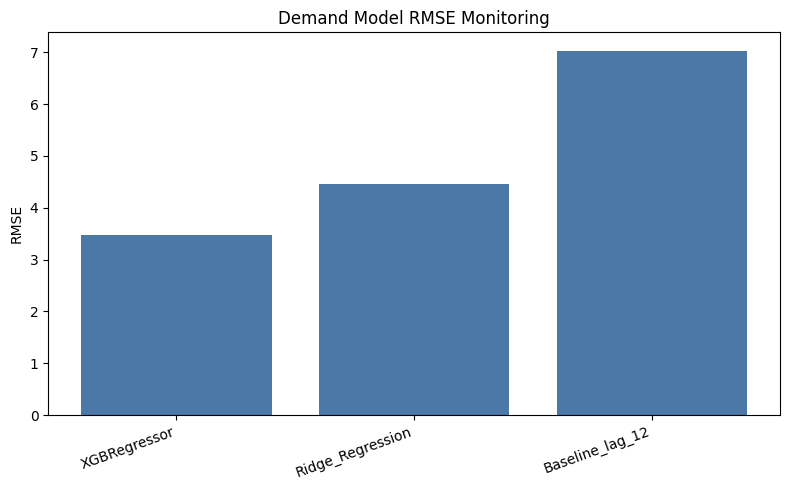

In [63]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(model_comparison["model"], model_comparison["RMSE"], color="#4c78a8")
ax.set_title("Demand Model RMSE Monitoring")
ax.set_ylabel("RMSE")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "monitoring_demand_rmse.png", dpi=160)
model_comparison


## Waiting Time Monitoring


,metric,value
0,Waiting time proxy before pricing,0.288270
1,Waiting time proxy after pricing,0.284203
2,Waiting Time Reduction %,1.410991


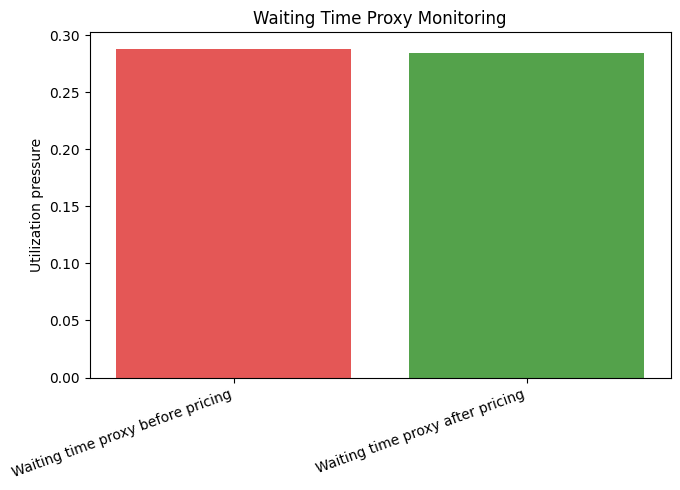

In [64]:
waiting_kpi = pd.read_csv(REPORT_DIR / "waiting_time_proxy_kpi.csv")

fig, ax = plt.subplots(figsize=(7, 5))
plot_waiting = waiting_kpi[waiting_kpi["metric"].isin(["Waiting time proxy before pricing", "Waiting time proxy after pricing"])]
ax.bar(plot_waiting["metric"], plot_waiting["value"], color=["#e45756", "#54a24b"])
ax.set_title("Waiting Time Proxy Monitoring")
ax.set_ylabel("Utilization pressure")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "monitoring_waiting_proxy.png", dpi=160)
waiting_kpi


## Customer Response Monitoring


,price_change_pct,customer_response_rate_pct,expected_volume_index
0,0.05,-2.5,0.975
1,0.10,-5.0,0.950
2,0.15,-7.5,0.925
3,0.20,-10.0,0.900


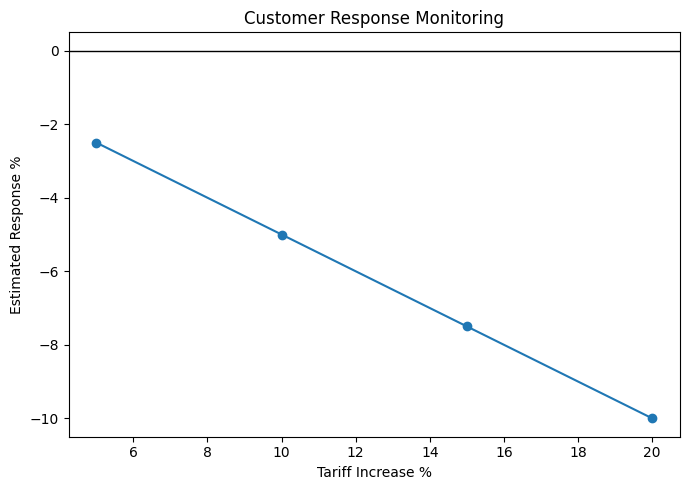

In [65]:
response_sensitivity = pd.read_csv(REPORT_DIR / "customer_response_sensitivity.csv")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(response_sensitivity["price_change_pct"] * 100, response_sensitivity["customer_response_rate_pct"], marker="o")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("Customer Response Monitoring")
ax.set_xlabel("Tariff Increase %")
ax.set_ylabel("Estimated Response %")
plt.tight_layout()
plt.savefig(FIG_DIR / "monitoring_customer_response.png", dpi=160)
response_sensitivity


## Alert Engine

In [66]:
alerts = []

revenue_gain = float(
    pricing_kpis.loc[
        pricing_kpis["KPI"] == "Revenue Gain %",
        "Value"
    ].iloc[0]
)

rmse = float(
    demand_kpis.loc[
        demand_kpis["KPI"].str.contains(
            "RMSE",
            case=False,
            na=False
        ),
        "Value"
    ].iloc[0]
)

waiting_reduction = float(
    waiting_kpi.loc[
        waiting_kpi["metric"] == "Waiting Time Reduction %",
        "value"
    ].iloc[0]
)

In [67]:
if revenue_gain < 0:
    alerts.append(
        "Revenue deterioration detected"
    )

if rmse > 5:
    alerts.append(
        "Forecast model drift suspected"
    )

if waiting_reduction < 0:
    alerts.append(
        "Waiting time increasing"
    )

In [68]:
alerts_df = pd.DataFrame(
    {"Alert": alerts}
)

alerts_df
if len(alerts) == 0:
    alerts.append(
        "No active operational alerts"
    )

In [69]:
alerts_df.to_csv(
    REPORT_DIR / "alerts.csv",
    index=False
)

## Model Drift Monitoring

In [70]:
baseline_rmse = 3.5

current_rmse = float(
    demand_kpis.loc[
       demand_kpis["KPI"].str.contains(
            "RMSE",
            case=False,
            na=False
        ),
        "Value"
    ].iloc[0]
)

drift_pct = (
    (current_rmse - baseline_rmse)
    /
    baseline_rmse
) * 100

In [71]:
if drift_pct > 20:
    model_status = "RETRAIN REQUIRED"
else:
    model_status = "HEALTHY"

In [72]:
model_monitoring = pd.DataFrame(
    {
        "baseline_rmse": [baseline_rmse],
        "current_rmse": [current_rmse],
        "drift_pct": [drift_pct],
        "status": [model_status]
    }
)

model_monitoring

,baseline_rmse,current_rmse,drift_pct,status
0,3.5,3.465161,-0.995399,HEALTHY


In [73]:
model_monitoring.to_csv(
    REPORT_DIR / "model_monitoring.csv",
    index=False
)

In [74]:
idle_hours = pd.read_csv(
    REPORT_DIR / "idle_time_by_hour.csv"
)

In [75]:
idle_hours.head()

,hour,avg_idle_time_hours
0,0,1.635180
1,1,1.261730
2,2,2.176749
3,3,4.361215
4,4,3.643079


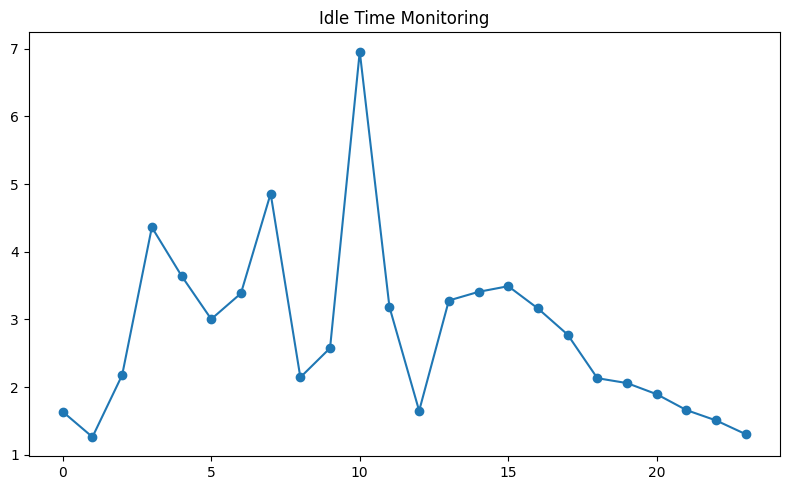

In [76]:
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    idle_hours["hour"],
    idle_hours["avg_idle_time_hours"],
    marker="o"
)

ax.set_title(
    "Idle Time Monitoring"
)

plt.tight_layout()

plt.savefig(
    FIG_DIR / "monitoring_idle_time.png",
    dpi=160
)

## Agent Feedback Loop

The monitoring agent should update future tariff decisions as follows:

1. If RMSE rises, retrain the Demand Prediction Agent and inspect feature drift.
2. If congestion remains high, increase surge strength or add location-specific thresholds.
3. If off-peak uplift is weak, test stronger discounts in low-demand windows.
4. If revenue gain declines, reduce discounts or recalibrate elasticity.
5. If customer response is more negative than assumed, lower tariff changes and prioritize non-price interventions.


In [77]:
actions = []

if drift_pct > 20:
    actions.append(
        "Retrain demand model"
    )

if revenue_gain < 0:
    actions.append(
        "Revisit tariff strategy"
    )

if waiting_reduction < 0:
    actions.append(
        "Increase off-peak incentives"
    )

if len(actions) == 0:
    actions.append(
        "System operating normally"
    )

In [78]:
feedback_loop = pd.DataFrame(
    {"Recommended Action": actions}
)

## Executive Dashboard Output


In [79]:
summary_dashboard = final_kpis.copy()
summary_dashboard["Interpretation"] = [
    "Dynamic pricing revenue lift versus fixed baseline",
    "Demand shifted into off-peak hours",
    "Change in average charger utilization after pricing",
    "Reduction in utilization-based waiting pressure",
    "Estimated customer volume response to tariff changes",
    "Revenue gain produced per average tariff change",
    "Demand model explanatory accuracy",
    "Demand model average large-error magnitude",
]
summary_dashboard.to_csv(REPORT_DIR / "executive_dashboard.csv", index=False)
summary_dashboard


,KPI,Value,Source,Interpretation
0,Revenue Gain %,0.978036,ACN,Dynamic pricing revenue lift versus fixed base...
1,Off-Peak Uplift %,-1.841452,UrbanEV,Demand shifted into off-peak hours
2,Utilization Improvement %,-1.410991,UrbanEV,Change in average charger utilization after pr...
3,Waiting Time Reduction %,1.410991,UrbanEV proxy,Reduction in utilization-based waiting pressure
4,Customer Response Rate %,-0.998470,ACN + elasticity,Estimated customer volume response to tariff c...
5,Pricing Efficiency Score,0.488466,ACN,Revenue gain produced per average tariff change
6,Demand Forecast Accuracy R2,0.980850,UrbanEV,Demand model explanatory accuracy
7,Demand Forecast RMSE,3.465161,UrbanEV,Demand model average large-error magnitude


## Monitoring Summary

In [80]:
monitoring_summary = pd.DataFrame(
    [
        {
            "Metric": "Revenue Gain %",
            "Value": revenue_gain
        },
        {
            "Metric": "RMSE",
            "Value": current_rmse
        },
        {
            "Metric": "Drift %",
            "Value": drift_pct
        },
        {
            "Metric": "Active Alerts",
            "Value": len(alerts)
        }
    ]
)

monitoring_summary

,Metric,Value
0,Revenue Gain %,0.978036
1,RMSE,3.465161
2,Drift %,-0.995399
3,Active Alerts,1.000000


In [81]:
monitoring_summary.to_csv(
    REPORT_DIR / "monitoring_learning_summary.csv",
    index=False
)

## Limitations and Future Work

- Monitoring outputs are based on simulated pricing response and should be validated with live pilots.
- Waiting time is a proxy, not observed queue duration.
- Future work should add charger outages, grid energy procurement costs, user satisfaction, weather, and local event data.
